In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/startup-success-prediction/startup data.csv


# Startup Success Predictor

## Problem Statement
The goal of this project is to predict whether a startup will succeed or fail based on
funding details, industry category, founding year, and geographical location.

## Definition of Success
- Success (1): Startup is Acquired or IPO
- Failure (0): Startup is Closed

## Model Used
- Logistic Regression (Binary Classification)

## Skills Demonstrated
- Exploratory Data Analysis (EDA)
- Data Cleaning & Preprocessing
- Handling Class Imbalance
- Logistic Regression
- Model Evaluation & Interpretation


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [6]:
df = pd.read_csv('/kaggle/input/startup-success-prediction/startup data.csv')
df.head()


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 14  age_first_

In [8]:
df['status'].value_counts()


status
acquired    597
closed      326
Name: count, dtype: int64

We convert startup status into a binary target variable:
- 1 → Successful (acquired, ipo)
- 0 → Failed (closed)


In [9]:
df = df[df['status'].isin(['acquired', 'ipo', 'closed'])]

df['success'] = df['status'].apply(
    lambda x: 1 if x in ['acquired', 'ipo'] else 0
)

df['success'].value_counts()


success
1    597
0    326
Name: count, dtype: int64

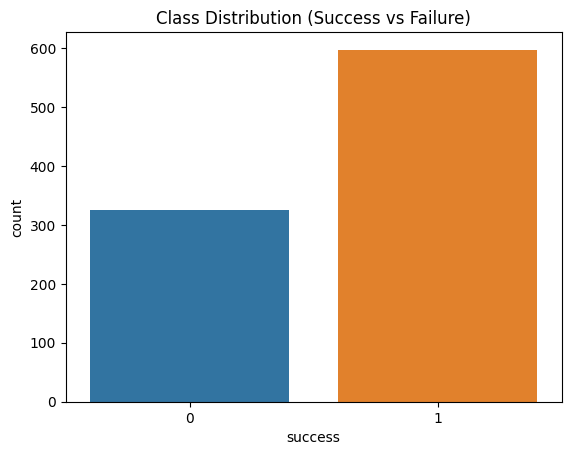

In [10]:
sns.countplot(x='success', data=df)
plt.title("Class Distribution (Success vs Failure)")
plt.show()


In [13]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.columns


Index(['unnamed:_0', 'state_code', 'latitude', 'longitude', 'zip_code', 'id',
       'city', 'unnamed:_6', 'name', 'labels', 'founded_at', 'closed_at',
       'first_funding_at', 'last_funding_at', 'age_first_funding_year',
       'age_last_funding_year', 'age_first_milestone_year',
       'age_last_milestone_year', 'relationships', 'funding_rounds',
       'funding_total_usd', 'milestones', 'state_code.1', 'is_ca', 'is_ny',
       'is_ma', 'is_tx', 'is_otherstate', 'category_code', 'is_software',
       'is_web', 'is_mobile', 'is_enterprise', 'is_advertising',
       'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting',
       'is_othercategory', 'object_id', 'has_vc', 'has_angel', 'has_rounda',
       'has_roundb', 'has_roundc', 'has_roundd', 'avg_participants',
       'is_top500', 'status', 'success'],
      dtype='object')

In [15]:
df = df[[
    'funding_total_usd',
    'funding_rounds',
    'age_first_funding_year',
    'age_last_funding_year',
    'category_code',
    'is_ca',
    'is_ny',
    'is_ma',
    'is_tx',
    'is_otherstate',
    'has_vc',
    'has_angel',
    'is_top500',
    'success'
]]


In [18]:
df['funding_total_usd'] = df['funding_total_usd'].fillna(0)
df['funding_rounds'] = df['funding_rounds'].fillna(0)

df['age_first_funding_year'] = df['age_first_funding_year'].fillna(
    df['age_first_funding_year'].median()
)

df['age_last_funding_year'] = df['age_last_funding_year'].fillna(
    df['age_last_funding_year'].median()
)

df['category_code'] = df['category_code'].fillna('unknown')


In [19]:
df = pd.get_dummies(
    df,
    columns=['category_code'],
    drop_first=True
)


In [20]:
X = df.drop('success', axis=1)
y = df['success']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
[[  0  65]
 [  0 120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        65
           1       0.65      1.00      0.79       120

    accuracy                           0.65       185
   macro avg       0.32      0.50      0.39       185
weighted avg       0.42      0.65      0.51       185

ROC-AUC Score: 0.6260897435897436


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [23]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)


funding_total_usd              5.398960e-09
funding_rounds                 1.066500e-15
is_top500                      6.749454e-16
is_ma                          2.499327e-16
is_ca                          1.625573e-16
category_code_enterprise       1.356705e-16
is_ny                          8.767541e-17
category_code_analytics        6.849160e-17
category_code_security         5.611227e-17
category_code_semiconductor    5.584320e-17
category_code_web              5.204394e-17
category_code_music            4.204986e-17
category_code_news             3.533938e-17
category_code_photo_video      2.524660e-17
category_code_health           2.474201e-17
dtype: float64